In [1]:
import requests
import pandas as pd
import geopandas as gpd
print(gpd.__version__)
import osmnx as ox
import osmnx.graph as og
print(ox.__version__)
import networkx as nx

import folium
import time


1.1.2
2.0.7


In [2]:
gdf = gpd.read_file("pilares.geojson")
gdf = gdf.to_crs(epsg="32614")

<Axes: >

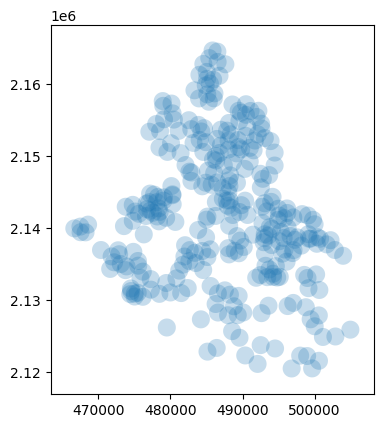

In [3]:
# Creamos buffers de los pilares
# Crear burbujas de isocronas
# Estas burbujas
buffers = gdf.to_crs(epsg="32614")
buffers['geometry'] = buffers.buffer(1250)
buffers.plot(alpha=0.25)

In [4]:
# Descargamos grafo de calles de CDMX de acuerdo a los buffers
# Obtener coordenadas del bounding box de los buffers
inicio = time.time()

bb = [float(x)
      for x in buffers.to_crs(4326).total_bounds]
print(bb)

G = ox.graph.graph_from_bbox(bb, network_type="all", 
                             simplify = False)
print(len(G.nodes), "nodos")
print(len(G.edges), "aristas")

fin = time.time()
print(f"Tiempo: {fin - inicio:.6f} segundos")

[-99.32946763194654, 19.166258104733817, -98.940736343211, 19.587800356524504]
864800 nodos
1739394 aristas
Tiempo: 127.298445 segundos


In [5]:
# Añadir longitudes a las aristas
G = ox.distance.add_edge_lengths(G)
# Hacer el grafo no dirigido 
G = ox.convert.to_undirected(G)

In [6]:
# Remover nodos aislados 
isolated_nodes = [n for n, d in G.degree() if d == 0]
G.remove_nodes_from(isolated_nodes)

In [7]:
# Obtener el componente gigante
largest_cc = max(nx.connected_components(G), key=len)
G = G.subgraph(largest_cc).copy()

In [8]:
# Limpiar atributos innecesarios de las aristas
for u, v, k, data in G.edges(keys=True, data=True):
    for attr in list(data.keys()):
        if attr not in ("osmid", "geometry", "length"):
            del data[attr]

In [5]:
# Proyectar el grafo a EPSG:32614
G = ox.project_graph(G, to_crs=32614)

In [6]:
print(len(G.nodes), "nodos")
print(len(G.edges), "aristas")

864800 nodos
1739394 aristas


In [13]:
ox.save_graph_geopackage(
    G,
    filepath="datos/grafo_calles_cdmx.gpkg")

In [7]:
# Encontrar nodos más cercanos a los pilares
nodos_cercanos = ox.distance.nearest_nodes(G,
  [p.x for p in gdf.geometry],
  [p.y for p in gdf.geometry])
print(len(nodos_cercanos))
# (Opcional) si hay nodos repetidos, reduce trabajo
nodos_unicos = pd.unique(nodos_cercanos)
print(len(nodos_unicos))

303
303


In [8]:
# Calles por nodo cercano
# Crear isocronas basadas en las calles
dist_fija = 750  # metros

partes = []
for node in nodos_cercanos:
    edges = ox.convert.graph_to_gdfs(
        ox.truncate.truncate_graph_dist(G, node, dist_fija),
        nodes=False
    ).copy()
    edges["node"] = node
    partes.append(edges[["node", "geometry"]])

iso_edges_por_nodo = gpd.GeoDataFrame(
    pd.concat(partes, ignore_index=True),
    crs=4326
).to_crs(32614)

iso_edges_por_nodo.head()

KeyboardInterrupt: 

In [8]:


# 1) edges del grafo completo (una sola vez)
edges_all = ox.convert.graph_to_gdfs(G, nodes=False, fill_edge_geometry=True).reset_index()
# suele traer columnas: u, v, key, geometry, length, ...

partes = []
nodos_unicos = pd.unique(nodos_cercanos)

for node in nodos_unicos:
    # 2) nodos alcanzables por distancia
    dist = nx.single_source_dijkstra_path_length(G, node, cutoff=dist_fija, weight="length")
    if len(dist) < 2:
        continue

    alcanzables = set(dist.keys())

    # 3) filtrar edges: (a) ambos extremos dentro (más estricto)
    e = edges_all[edges_all["u"].isin(alcanzables) & edges_all["v"].isin(alcanzables)][["geometry"]].copy()

    # alternativa (b) más “grande”: al menos un extremo dentro (incluye borde)
    # e = edges_all[edges_all["u"].isin(alcanzables) | edges_all["v"].isin(alcanzables)][["geometry"]].copy()

    if e.empty:
        continue

    e["node"] = node
    partes.append(e)

iso_edges_por_nodo = gpd.GeoDataFrame(pd.concat(partes, ignore_index=True), crs=G.graph["crs"])

NameError: name 'dist_fija' is not defined

<Axes: >

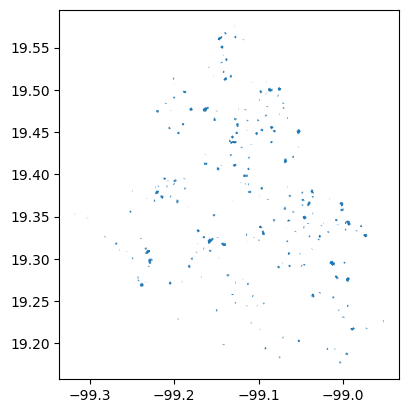

In [16]:
iso_edges_por_nodo.plot()

In [17]:
iso_edges_por_nodo.to_file("prueba.gpkg")

In [68]:
# Calles por nodo cercano
# Crear isocronas basadas en las calles
dist_fija = 750  # metros

partes = []
for node in nodos_unicos:
    Gsub = ox.truncate.truncate_graph_dist(G, node, dist_fija)

    # Evita el error cuando el subgrafo queda vacío
    if Gsub.number_of_edges() == 0:
        continue

    edges = ox.convert.graph_to_gdfs(
        Gsub,
        nodes=False,
        fill_edge_geometry=True
    )[["geometry"]]

    # 3) Evita copy() grande: crea un DF mínimo y agrega el id del nodo
    edges = edges.assign(node=node)

    partes.append(edges[["node", "geometry"]])

iso_edges_por_nodo = gpd.GeoDataFrame(
    pd.concat(partes, ignore_index=True),
    crs=32614
)

iso_edges_por_nodo.head()

,node,geometry
0,268533822,"LINESTRING (483333.897 2159097.045, 483335.966..."
1,268533822,"LINESTRING (483333.897 2159097.045, 483320.425..."
2,268533822,"LINESTRING (483511.555 2159240.599, 483522.481..."
3,268533822,"LINESTRING (483513.093 2159235.176, 483511.555..."
4,268533822,"LINESTRING (482959.214 2159250.841, 482949.827..."


<Axes: >

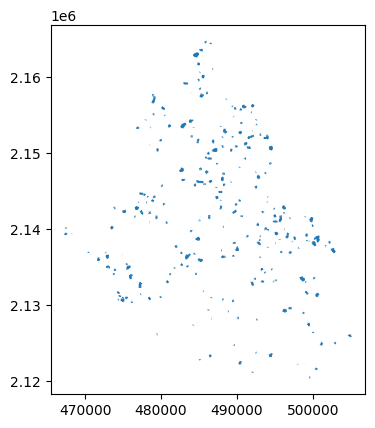

In [69]:
iso_edges_por_nodo.plot()

In [70]:
# Guardamos isocronas
iso_edges_por_nodo.to_file("datos/calles_750m_pilares.gpkg", driver="GPKG")

In [71]:
isochrone_streets = iso_edges_por_nodo.copy()

In [72]:
print("Núnmero de segmentos en isocronas:")
print(isochrone_streets.shape[0])
print("Núnmero de nodos en isocronas:")
print(isochrone_streets['node'].nunique())

Núnmero de segmentos en isocronas:
1998
Núnmero de nodos en isocronas:
242


In [73]:
isochrone_streets.head(1)

,node,geometry
0,268533822,"LINESTRING (483333.897 2159097.045, 483335.966..."


In [74]:
gdf_disuelto = isochrone_streets.dissolve(by="node", as_index=False)
print("Núnmero de segmentos en isocronas:")
print(gdf_disuelto.shape[0])
print("Núnmero de nodos en isocronas:")
print(gdf_disuelto['node'].nunique())

Núnmero de segmentos en isocronas:
242
Núnmero de nodos en isocronas:
242


In [19]:
# Guardamos isocronas
gdf_disuelto.to_file("datos/calles_750m_pilares_disuelto.gpkg", driver="GPKG")

In [22]:
isochrone_streets = gdf_disuelto.copy()

<Axes: >

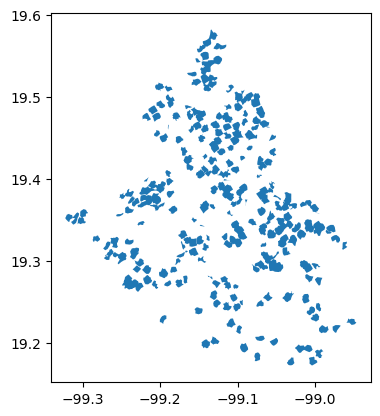

In [ ]:
#
isochrone_approx = (
  isochrone_streets
  .concave_hull(ratio = 0.5)
)

isochrone_approx.plot()

In [25]:
print(isochrone_approx.crs)
print(isochrone_streets.crs)
# print(pilares.crs)

EPSG:32614
EPSG:32614


In [26]:
isochrone_approx = isochrone_approx.to_crs(epsg=4326)
isochrone_streets = isochrone_streets.to_crs(epsg=4326)

In [ ]:
isochrone_approx.to_file("datos/isocronas_calles_750m_pilares_hull.gpkg", driver="GPKG")
isochrone_streets.to_file("datos/calles_750m_pilares.gpkg", driver="GPKG")

In [ ]:
m = folium.Map(
  tiles = None,
  zoom_start = 13, max_bounds = True,
  location = [(bb[0] + bb[2]) / 2, (bb[1] + bb[3]) / 2],
  min_lon = bb[0], min_lat = bb[1], 
  max_lon = bb[2], max_lat = bb[3]
)

folium.TileLayer("CartoDB Positron", overlay = True).add_to(m)


isochrone_approx.explore(
  m = m, name = "Approximate isochrone", tooltip = False,
  style_kwds = dict(color = "red", fill = False, weight = 3))

isochrone_streets.explore(
  m = m, name = "Streets isochrone", tooltip = False,
  style_kwds = dict(color = "orange", weight = 1))

gdf.explore(
  m = m, name = "Pilares", tooltip = "nombre",
  style_kwds = dict(color = "red", fill = False, radius = 6))

folium.LayerControl().add_to(m)
m